In [2]:
!pip install pandas numpy scikit-learn xgboost matplotlib seaborn joblib shap


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier

import joblib

import warnings
warnings.filterwarnings("ignore")

print("CreditLens environment ready!")

CreditLens environment ready!


In [4]:
np.random.seed(42)

n = 5000

data = pd.DataFrame({
    "monthly_revenue": np.random.lognormal(mean=11, sigma=0.5, size=n),
    "monthly_expenses": np.random.lognormal(mean=10.5, sigma=0.5, size=n),
    "total_debt": np.random.lognormal(mean=10.5, sigma=0.7, size=n),
    "monthly_emi": np.random.lognormal(mean=9, sigma=0.6, size=n),
    "average_balance": np.random.lognormal(mean=10, sigma=0.7, size=n),
    "late_payment_count": np.random.poisson(lam=1.5, size=n),
    "total_transactions": np.random.poisson(lam=80, size=n),
    "avg_transaction_value": np.random.lognormal(mean=7, sigma=0.7, size=n),
    "revenue_growth": np.random.normal(loc=0.08, scale=0.15, size=n),
    "expense_growth": np.random.normal(loc=0.07, scale=0.15, size=n),
    "cashflow_volatility": np.random.uniform(0.05, 0.8, size=n),
    "credit_utilization": np.random.uniform(0.05, 0.95, size=n)
})

data.head()

,monthly_revenue,monthly_expenses,total_debt,monthly_emi,average_balance,late_payment_count,total_transactions,avg_transaction_value,revenue_growth,expense_growth,cashflow_volatility,credit_utilization
0,76753.715638,29381.489876,22585.280972,7434.942091,28107.743124,2,73,1385.719065,0.058445,0.096695,0.747534,0.902669
1,55874.749541,28949.058064,29323.671676,7945.861116,26858.201641,2,84,1496.238942,0.345273,0.123847,0.243180,0.518204
2,82771.929654,14796.980426,23904.768988,8421.783713,11435.022887,4,81,2772.941671,0.113575,0.342771,0.696864,0.832700
3,128221.552839,30790.297532,39233.750318,14301.459543,33047.756310,1,79,1165.129993,-0.130700,0.236068,0.629385,0.292430
4,53259.065469,52387.041542,83954.055682,5175.388123,7761.587190,1,61,1684.930119,0.034723,0.017451,0.336458,0.601133


In [5]:
data["debt_to_income"] = (
    data["monthly_emi"] / data["monthly_revenue"]
)

data["expense_ratio"] = (
    data["monthly_expenses"] / data["monthly_revenue"]
)

data["cashflow"] = (
    data["monthly_revenue"] - data["monthly_expenses"]
)

data["repayment_score"] = (
    1 / (1 + data["late_payment_count"])
)

data["transaction_consistency"] = (
    data["total_transactions"] /
    (data["avg_transaction_value"] + 1)
)

data["cash_reserve_ratio"] = (
    data["average_balance"] /
    (data["monthly_expenses"] + 1)
)

data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.fillna(0, inplace=True)

data.head()

,monthly_revenue,monthly_expenses,total_debt,monthly_emi,average_balance,late_payment_count,total_transactions,avg_transaction_value,revenue_growth,expense_growth,cashflow_volatility,credit_utilization,debt_to_income,expense_ratio,cashflow,repayment_score,transaction_consistency,cash_reserve_ratio
0,76753.715638,29381.489876,22585.280972,7434.942091,28107.743124,2,73,1385.719065,0.058445,0.096695,0.747534,0.902669,0.096868,0.382802,47372.225763,0.333333,0.052642,0.956615
1,55874.749541,28949.058064,29323.671676,7945.861116,26858.201641,2,84,1496.238942,0.345273,0.123847,0.243180,0.518204,0.142208,0.518106,26925.691477,0.333333,0.056103,0.927743
2,82771.929654,14796.980426,23904.768988,8421.783713,11435.022887,4,81,2772.941671,0.113575,0.342771,0.696864,0.832700,0.101747,0.178768,67974.949227,0.200000,0.029200,0.772742
3,128221.552839,30790.297532,39233.750318,14301.459543,33047.756310,1,79,1165.129993,-0.130700,0.236068,0.629385,0.292430,0.111537,0.240134,97431.255306,0.500000,0.067745,1.073282
4,53259.065469,52387.041542,83954.055682,5175.388123,7761.587190,1,61,1684.930119,0.034723,0.017451,0.336458,0.601133,0.097174,0.983627,872.023927,0.500000,0.036182,0.148156


In [6]:
risk_score = (
    0.30 * data["debt_to_income"] +
    0.20 * data["expense_ratio"] +
    0.20 * data["late_payment_count"] / 10 +
    0.15 * data["cashflow_volatility"] +
    0.15 * data["credit_utilization"]
)

threshold = risk_score.quantile(0.65)

data["high_risk"] = (risk_score > threshold).astype(int)

data["high_risk"].value_counts()

,count
high_risk,
0,3250
1,1750


In [7]:
data.describe()

,monthly_revenue,monthly_expenses,total_debt,monthly_emi,average_balance,late_payment_count,total_transactions,avg_transaction_value,revenue_growth,expense_growth,cashflow_volatility,credit_utilization,debt_to_income,expense_ratio,cashflow,repayment_score,transaction_consistency,cash_reserve_ratio,high_risk
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,67968.806428,41067.721863,46713.045728,9811.254655,27507.795403,1.493000,79.951000,1381.237192,0.082566,0.067266,0.424985,0.505312,0.185387,0.773144,26901.084565,0.519552,0.094020,0.867965,0.350000
std,36193.245846,22181.403917,37081.591469,6576.279634,20958.544264,1.225011,8.853151,1070.129952,0.151468,0.152838,0.214945,0.260188,0.171497,0.613099,42609.358140,0.277358,0.077077,0.917829,0.477017
min,11841.508767,5109.208987,3418.970050,801.251438,1705.202992,0.000000,51.000000,80.454738,-0.422723,-0.459782,0.050098,0.050394,0.007521,0.027951,-151972.729492,0.125000,0.007113,0.025411,0.000000
25%,43090.053967,25763.358555,22865.386601,5438.135590,13477.378948,1.000000,74.000000,676.293122,-0.018489,-0.032828,0.238500,0.279097,0.080595,0.370458,1215.947433,0.333333,0.045592,0.330306,0.000000
50%,60278.623828,36000.019598,36568.489827,8197.262064,21903.204338,1.000000,80.000000,1080.668093,0.083873,0.069225,0.431221,0.509785,0.134661,0.600238,22688.346406,0.500000,0.072968,0.599260,0.000000
75%,83533.690318,50950.968902,58271.824776,12381.624984,34732.270087,2.000000,86.000000,1734.766776,0.183614,0.168134,0.607870,0.733664,0.225449,0.968724,47561.804290,0.500000,0.117716,1.086536,1.000000
max,426393.903114,212039.444177,400407.210541,119068.061100,275941.742348,7.000000,111.000000,10280.802701,0.590847,0.586589,0.799900,0.949873,1.970754,7.214692,398798.057225,1.000000,1.055801,24.954906,1.000000


In [8]:
print("Dataset shape:", data.shape)
print("\nRisk distribution:")
print(data["high_risk"].value_counts())

print("\nMissing values:")
print(data.isnull().sum().sum())

Dataset shape: (5000, 19)

Risk distribution:
high_risk
0    3250
1    1750
Name: count, dtype: int64

Missing values:
0


In [9]:
features = [
    "monthly_revenue",
    "monthly_expenses",
    "total_debt",
    "monthly_emi",
    "average_balance",
    "late_payment_count",
    "total_transactions",
    "avg_transaction_value",
    "revenue_growth",
    "expense_growth",
    "cashflow_volatility",
    "credit_utilization",
    "debt_to_income",
    "expense_ratio",
    "cashflow",
    "repayment_score",
    "transaction_consistency",
    "cash_reserve_ratio"
]

X = data[features]
y = data["high_risk"]

print("Features:", len(features))
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: 18
X shape: (5000, 18)
y shape: (5000,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4000
Testing samples: 1000


In [11]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("Random Forest training completed!")


Random Forest training completed!


In [12]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.933
Precision: 0.9463722397476341
Recall   : 0.8571428571428571
F1 Score : 0.8995502248875562
ROC-AUC  : 0.9884835164835164


In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       650
           1       0.95      0.86      0.90       350

    accuracy                           0.93      1000
   macro avg       0.94      0.92      0.92      1000
weighted avg       0.93      0.93      0.93      1000



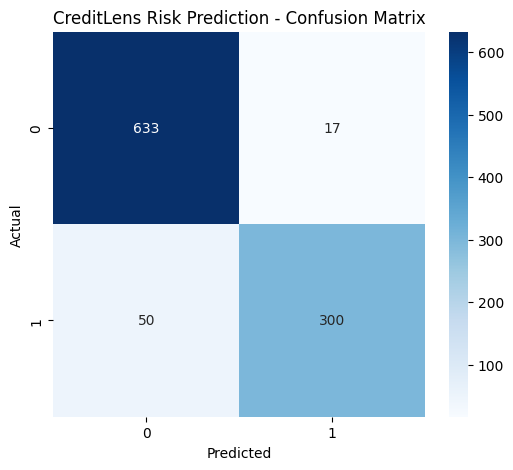

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CreditLens Risk Prediction - Confusion Matrix")
plt.show()

In [15]:
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

importance

,feature,importance
14,cashflow,0.241961
13,expense_ratio,0.207907
0,monthly_revenue,0.122234
12,debt_to_income,0.086191
11,credit_utilization,0.073986
1,monthly_expenses,0.050053
10,cashflow_volatility,0.048419
3,monthly_emi,0.034344
17,cash_reserve_ratio,0.020734
15,repayment_score,0.016574


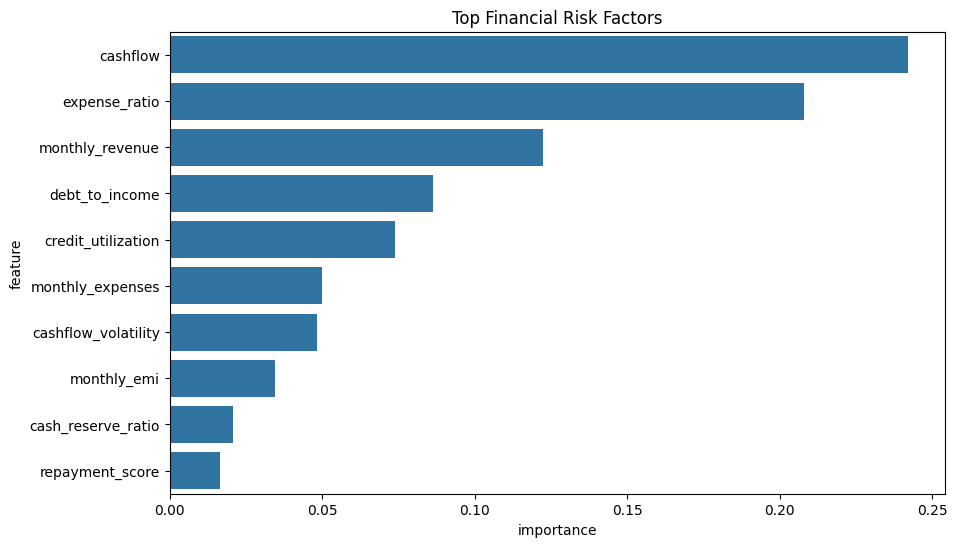

In [16]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance.head(10),
    x="importance",
    y="feature"
)

plt.title("Top Financial Risk Factors")
plt.show()

In [17]:
joblib.dump(model, "creditlens_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [18]:
print("Dataset shape:", data.shape)
print(data["high_risk"].value_counts())
print(classification_report(y_test, y_pred))

Dataset shape: (5000, 19)
high_risk
0    3250
1    1750
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       650
           1       0.95      0.86      0.90       350

    accuracy                           0.93      1000
   macro avg       0.94      0.92      0.92      1000
weighted avg       0.93      0.93      0.93      1000



In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        random_state=42,
        eval_metric="logloss"
    )
}

In [20]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.953,0.939130,0.925714,0.932374,0.991437
1,Random Forest,0.933,0.946372,0.857143,0.899550,0.988484
2,XGBoost,0.975,0.979351,0.948571,0.963716,0.997407


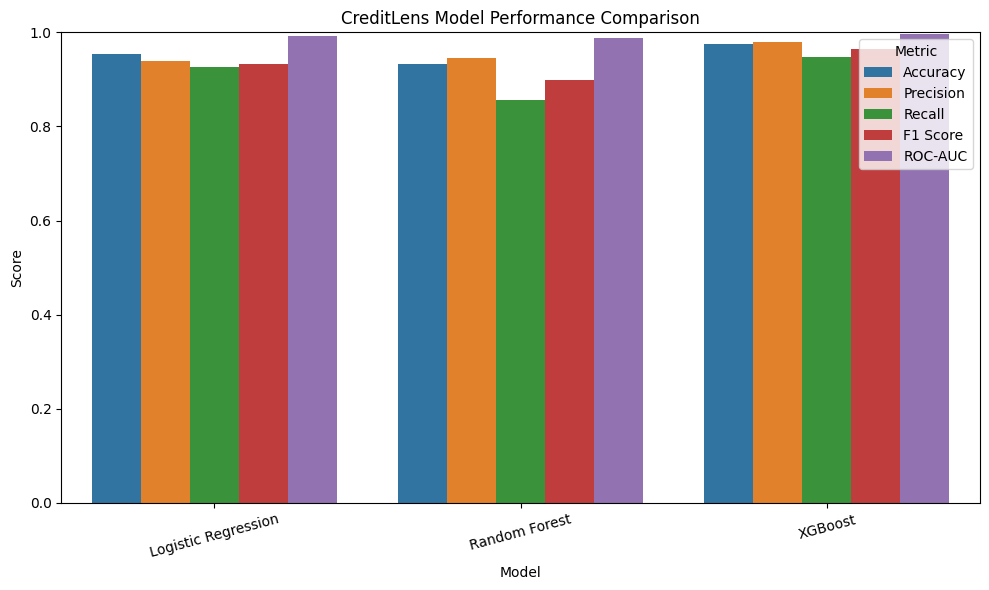

In [21]:
plt.figure(figsize=(10, 6))

results_melted = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    var_name="Metric",
    value_name="Score"
)

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.ylim(0, 1)
plt.title("CreditLens Model Performance Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [22]:
results_df.to_csv(
    "creditlens_model_comparison.csv",
    index=False
)

print("Model comparison saved!")

Model comparison saved!


CREDITLENS AI — DEVELOPMENT LOG

Date: 25 August 2026

Milestone 1: ML Prototype

Dataset:
- 5,000 synthetic SME financial records
- 19 features/variables
- Binary risk classification

Initial Model:
- Random Forest

Initial Results:
- Accuracy: 93%
- Precision: 0.94
- Recall: 0.92
- F1 Score: 0.92

Important Note:
The initial dataset and risk labels are synthetic and are being
used for prototype development. A public real-world credit-risk
dataset will be used for the final experimental evaluation and
research-paper analysis.

In [23]:
# ============================================
# CREDITLENS CREDIT INTELLIGENCE SCORE
# ============================================

def calculate_credit_score(row):
    score = 100

    # Debt burden
    if row["debt_to_income"] > 0.50:
        score -= 20
    elif row["debt_to_income"] > 0.35:
        score -= 10

    # Expense burden
    if row["expense_ratio"] > 0.85:
        score -= 20
    elif row["expense_ratio"] > 0.70:
        score -= 10

    # Late payments
    if row["late_payment_count"] >= 5:
        score -= 20
    elif row["late_payment_count"] >= 3:
        score -= 10
    elif row["late_payment_count"] >= 1:
        score -= 5

    # Cash-flow stability
    if row["cashflow_volatility"] > 0.60:
        score -= 15
    elif row["cashflow_volatility"] > 0.40:
        score -= 8

    # Credit utilization
    if row["credit_utilization"] > 0.80:
        score -= 15
    elif row["credit_utilization"] > 0.60:
        score -= 8

    # Revenue growth
    if row["revenue_growth"] > 0.10:
        score += 5
    elif row["revenue_growth"] < -0.10:
        score -= 10

    return max(0, min(100, score))


data["credit_score"] = data.apply(
    calculate_credit_score,
    axis=1
)

data[[
    "credit_score",
    "high_risk"
]].head(10)

,credit_score,high_risk
0,65,0
1,100,0
2,65,0
3,70,0
4,67,0
5,87,0
6,80,0
7,79,0
8,80,0
9,80,0


In [24]:
def risk_category(score):

    if score >= 75:
        return "Low Risk"

    elif score >= 50:
        return "Medium Risk"

    else:
        return "High Risk"


data["risk_category"] = data["credit_score"].apply(
    risk_category
)

data["risk_category"].value_counts()

,count
risk_category,
Low Risk,3049
Medium Risk,1712
High Risk,239


In [25]:
def calculate_financial_health(row):

    score = 0

    # Revenue stability
    if row["revenue_growth"] >= 0.05:
        score += 20
    elif row["revenue_growth"] >= -0.05:
        score += 12
    else:
        score += 5

    # Cash flow
    if row["cashflow"] > 0:
        score += 20
    else:
        score += 5

    # Debt
    if row["debt_to_income"] < 0.30:
        score += 20
    elif row["debt_to_income"] < 0.50:
        score += 12
    else:
        score += 5

    # Repayment behavior
    if row["late_payment_count"] == 0:
        score += 20
    elif row["late_payment_count"] <= 2:
        score += 12
    else:
        score += 5

    # Transaction consistency
    if row["transaction_consistency"] > 1:
        score += 20
    else:
        score += 10

    return min(100, score)


data["financial_health_score"] = data.apply(
    calculate_financial_health,
    axis=1
)

data[
    [
        "credit_score",
        "financial_health_score",
        "risk_category"
    ]
].head(10)

,credit_score,financial_health_score,risk_category
0,65,82,Medium Risk
1,100,82,Low Risk
2,65,75,Medium Risk
3,70,67,Medium Risk
4,67,74,Medium Risk
5,87,82,Low Risk
6,80,74,Low Risk
7,79,74,Low Risk
8,80,74,Low Risk
9,80,74,Low Risk


In [27]:
def generate_risk_report(index):

    row = data.iloc[index]

    print("=" * 50)
    print("           CREDITLENS AI")
    print("       SME RISK INTELLIGENCE")
    print("=" * 50)

    print(f"\nBusiness ID: SME-{index + 1:04d}")

    print("\nCREDIT INTELLIGENCE")
    print("-" * 30)

    print(f"Credit Score       : {row['credit_score']}/100")
    print(f"Risk Category      : {row['risk_category']}")
    print(f"Financial Health   : {row['financial_health_score']}/100")

    print("\nFINANCIAL INFORMATION")
    print("-" * 30)

    print(f"Monthly Revenue    : ₹{row['monthly_revenue']:,.0f}")
    print(f"Monthly Expenses   : ₹{row['monthly_expenses']:,.0f}")
    print(f"Total Debt         : ₹{row['total_debt']:,.0f}")
    print(f"Average Balance    : ₹{row['average_balance']:,.0f}")

    print("\nRISK INDICATORS")
    print("-" * 30)

    print(f"Debt/Income Ratio  : {row['debt_to_income']:.2f}")
    print(f"Expense Ratio      : {row['expense_ratio']:.2f}")
    print(f"Late Payments      : {row['late_payment_count']}")
    print(f"Credit Utilization : {row['credit_utilization']:.2f}")

    print("\n" + "=" * 50)

In [28]:
generate_risk_report(10)

           CREDITLENS AI
       SME RISK INTELLIGENCE

Business ID: SME-0011

CREDIT INTELLIGENCE
------------------------------
Credit Score       : 72/100
Risk Category      : Medium Risk
Financial Health   : 60/100

FINANCIAL INFORMATION
------------------------------
Monthly Revenue    : ₹47,491
Monthly Expenses   : ₹80,754
Total Debt         : ₹69,241
Average Balance    : ₹38,641

RISK INDICATORS
------------------------------
Debt/Income Ratio  : 0.14
Expense Ratio      : 1.70
Late Payments      : 0
Credit Utilization : 0.37



In [29]:
from sklearn.ensemble import IsolationForest

anomaly_features = [
    "monthly_revenue",
    "monthly_expenses",
    "total_debt",
    "average_balance",
    "total_transactions",
    "avg_transaction_value"
]

anomaly_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

data["anomaly"] = anomaly_model.fit_predict(
    data[anomaly_features]
)

data["anomaly_status"] = data["anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

data["anomaly_status"].value_counts()

,count
anomaly_status,
Normal,4750
Anomaly,250


In [30]:
data[
    [
        "credit_score",
        "financial_health_score",
        "risk_category",
        "anomaly_status"
    ]
].head(20)

,credit_score,financial_health_score,risk_category,anomaly_status
0,65,82,Medium Risk,Normal
1,100,82,Low Risk,Normal
2,65,75,Medium Risk,Normal
3,70,67,Medium Risk,Normal
4,67,74,Medium Risk,Normal
5,87,82,Low Risk,Normal
6,80,74,Low Risk,Normal
7,79,74,Low Risk,Normal
8,80,74,Low Risk,Normal
9,80,74,Low Risk,Normal
